# Hiring bias: quick EDA
Based on `../brief/Hiring_Bias_Datathon_Team_Brief.pdf`: check whether the resume and job data are suitable for a paired hiring audit. Focus on quality, coverage and text length; these data alone cannot measure behavioural or activation-space bias.

The public sources below are not verified as Hannah's scrubbed datasets. Avoid displaying raw personal text.

In [1]:
from pathlib import Path
from io import BytesIO
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the existing download; install kagglehub if downloading for the first time.
resume_path = Path.home() / ".cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1"
if not resume_path.exists():
    import kagglehub
    resume_path = Path(kagglehub.dataset_download("snehaanbhawal/resume-dataset/versions/1"))
resumes = pd.read_csv(resume_path / "Resume/Resume.csv")

url = "https://huggingface.co/datasets/datastax/linkedin_job_listings/resolve/main/postings.csv"
response = requests.get(url, timeout=120)
response.raise_for_status()
df = pd.read_csv(BytesIO(response.content))
jobs = df  # Keep the original df variable available.


## 1. Basic quality
Count blank text as missing. Duplicate text is compared after collapsing whitespace; repeated job descriptions may be legitimate reposts.

In [2]:
datasets = {"Resumes": (resumes, "Resume_str", "ID"),
            "Jobs": (jobs, "description", "job_id")}
quality = []
for name, (data, text_col, id_col) in datasets.items():
    text = data[text_col].fillna("").str.split().str.join(" ")
    quality.append({"dataset": name, "rows": len(data), "columns": data.shape[1],
                    "missing/blank text": text.eq("").sum(),
                    "repeated IDs": data[id_col].duplicated().sum(),
                    "repeated nonblank text": text[text.ne("")].duplicated().sum()})
display(pd.DataFrame(quality).set_index("dataset"))

# Fields useful for matching resumes to jobs.
fields = ["title", "description", "formatted_experience_level", "skills_desc"]
display(jobs[fields].replace(r"^\s*$", pd.NA, regex=True).isna()
        .mean().mul(100).round(1).rename("Jobs missing (%)").to_frame())

,rows,columns,missing/blank text,repeated IDs,repeated nonblank text
dataset,,,,,
Resumes,2484,4,1,0,2
Jobs,123849,31,7,0,16292


,Jobs missing (%)
title,0.0
description,0.0
formatted_experience_level,23.7
skills_desc,98.0


## 2. Coverage
Check resume categories and job experience levels before selecting audit examples.

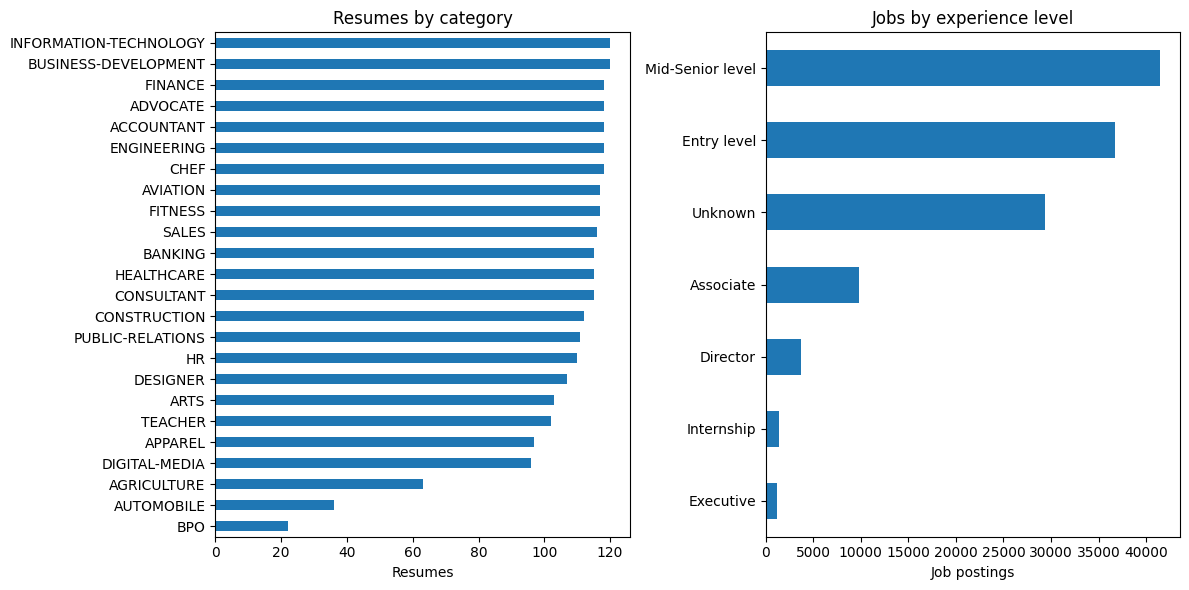

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
resumes["Category"].fillna("Unknown").value_counts().sort_values().plot.barh(ax=axes[0])
axes[0].set(title="Resumes by category", xlabel="Resumes", ylabel="")
jobs["formatted_experience_level"].fillna("Unknown").value_counts().sort_values().plot.barh(ax=axes[1])
axes[1].set(title="Jobs by experience level", xlabel="Job postings", ylabel="")
plt.tight_layout()
plt.show()

## 3. Text length
Whitespace word counts approximate input size, not model tokens. Exclude blank text here.

,Resumes,Jobs
Minimum,113.0,1.0
Median,757.0,477.0
95th percentile,1399.0,1074.0
Maximum,5190.0,3400.0


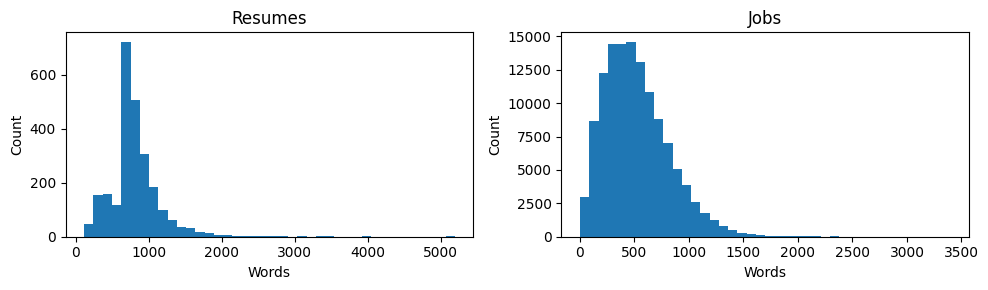

In [4]:
lengths = {}
for name, (data, text_col, _) in datasets.items():
    words = data[text_col].fillna("").str.split().str.len()
    lengths[name] = words[words.gt(0)]
display(pd.DataFrame({name: values.quantile([0, .5, .95, 1])
                      for name, values in lengths.items()})
        .set_axis(["Minimum", "Median", "95th percentile", "Maximum"]).round(0))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (name, words) in zip(axes, lengths.items()):
    words.plot.hist(bins=40, ax=ax)
    ax.set(title=name, xlabel="Words", ylabel="Count")
plt.tight_layout()
plt.show()

## Takeaways
- **2,484 resumes across 24 categories; 123,849 job postings.** This is a larger public job source than the brief describes, not a verified scrubbed sample.
- Resume categories range from **22 to 120 examples**. Sample across categories so larger groups do not dominate the audit.
- Resumes include **1 blank text and 2 repeated texts**. Jobs include **7 missing/blank descriptions**, **16,292 repeated nonblank descriptions** and **23.7% missing experience levels** (skills descriptions are **98.0% missing**). Review duplicates and exclude blank inputs before sampling.
- Median lengths are **757 words per resume** and **477 per job**; inspect long inputs before choosing a model context limit.
- Next: verify scrubbing, select relevant resume/job pairs, then vary only the test name. Hiring outputs and model activations are needed to evaluate the two kinds of bias; neither dataset supplies those measurements.